In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
from pyhydra.climate.spatial_analysis import (
    fit_gev_mle,
    fit_gev_lmom,
    fit_gev_bayes,
    return_level,
    return_level_bayes,
    regional_index_flood,
    fit_regional_gev,
    regional_return_levels,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Regional Frequency Analysis (GEV)

This notebook demonstrates **at-site** and **regional** flood frequency analysis
using the Generalised Extreme Value (GEV) distribution.

| Function | Method | Dependencies |
|----------|--------|--------------|
| `fit_gev_mle` | Maximum Likelihood | `scipy` |
| `fit_gev_lmom` | L-moments | `lmoments3` |
| `fit_gev_bayes` | Bayesian MCMC | `pystan` |
| `return_level` | Point return level from MLE/L-mom params | `scipy` |
| `return_level_bayes` | Posterior return-level CI | — |
| `regional_index_flood` | Index-flood rescaling | `scipy` |
| `fit_regional_gev` | Regional GEV on standardised series | `scipy` / `lmoments3` |
| `regional_return_levels` | Return levels at all stations | — |

### Installation

```bash
pip install scipy lmoments3
pip install pystan    # Bayesian method only
```

---
## Synthetic dataset

We generate annual maximum discharges at 8 stations from GEV distributions
with shared shape parameter (homogeneous region assumption) but different
location/scale (index-flood structure).

In [3]:
from scipy.stats import genextreme

rng = np.random.default_rng(42)

# Station characteristics
stations = {
    "Ebro":     {"mu": 1200, "sigma": 350, "xi": 0.15, "n": 40},
    "Tajo":     {"mu":  900, "sigma": 260, "xi": 0.12, "n": 35},
    "Duero":    {"mu": 1100, "sigma": 310, "xi": 0.14, "n": 45},
    "Guadalquivir": {"mu": 800, "sigma": 240, "xi": 0.10, "n": 38},
    "Turia":    {"mu":  350, "sigma": 120, "xi": 0.18, "n": 30},
    "Segura":   {"mu":  280, "sigma":  90, "xi": 0.20, "n": 25},
    "Miño":     {"mu":  700, "sigma": 200, "xi": 0.08, "n": 42},
    "Jucar":    {"mu":  420, "sigma": 130, "xi": 0.16, "n": 33},
}

am_data = {}
for name, p in stations.items():
    # genextreme uses -xi convention in scipy
    am_data[name] = genextreme.rvs(-p["xi"], loc=p["mu"], scale=p["sigma"],
                                    size=p["n"], random_state=rng)

# Quick overview
summary = pd.DataFrame({
    name: {"n": len(v), "mean": v.mean(), "std": v.std(),
           "max": v.max(), "min": v.min()}
    for name, v in am_data.items()
}).T.round(0)
print(summary)

                 n    mean    std     max    min
Ebro          40.0  1504.0  516.0  2932.0  833.0
Tajo          35.0  1003.0  238.0  1436.0  523.0
Duero         45.0  1280.0  380.0  2482.0  724.0
Guadalquivir  38.0   895.0  281.0  1693.0  498.0
Turia         30.0   482.0  224.0  1286.0  221.0
Segura        25.0   329.0  134.0   746.0  167.0
Miño          42.0   844.0  252.0  1474.0  436.0
Jucar         33.0   436.0  143.0   819.0  262.0


---
## 1. At-site fitting

Three estimation methods for a single station.

In [4]:
# Pick one station for the at-site demo
station_name = "Ebro"
data = am_data[station_name]

print(f"Station: {station_name}  |  n = {len(data)}  |  mean = {data.mean():.0f} m³/s")

Station: Ebro  |  n = 40  |  mean = 1504 m³/s


In [5]:
# --- MLE ---
params_mle = fit_gev_mle(data)
print("MLE parameters:")
print(f"  mu = {params_mle['mu']:.1f}  sigma = {params_mle['sigma']:.1f}  xi = {params_mle['xi']:.3f}")

MLE parameters:
  mu = 1244.6  sigma = 341.9  xi = 0.168


In [6]:
# --- L-moments (requires lmoments3) ---
try:
    params_lmom = fit_gev_lmom(data)
    print("L-moments parameters:")
    print(f"  mu = {params_lmom['mu']:.1f}  sigma = {params_lmom['sigma']:.1f}  xi = {params_lmom['xi']:.3f}")
except ImportError:
    params_lmom = params_mle   # fallback for the rest of the notebook
    print("(lmoments3 not installed — pip install lmoments3)")

L-moments parameters:
  mu = 1250.4  sigma = 367.7  xi = -0.103


In [7]:
# Bayesian MCMC — 2 chains / 500 samples for speed (use 4 / 1000 for production)
posterior = fit_gev_bayes(data, n_chains=2, n_samples=500)
print("Bayesian GEV posterior (Ebro station):")
print(posterior.describe().round(2))


Building...

Building: found in cache, done.

Messages from stanc:


Warning in '/var/folders/44/dw7p6q9108xcc4mmh_f7q1vc0000gn/T/httpstan_3c6vlplv/model_e5dxufxs.stan', line 24, column 12: A
    control flow statement depends on parameter(s): mu_raw, sigma, xi.
Warning in '/var/folders/44/dw7p6q9108xcc4mmh_f7q1vc0000gn/T/httpstan_3c6vlplv/model_e5dxufxs.stan', line 22, column 8: A
    control flow statement depends on parameter(s): xi.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.


Sampling:   0%

...

warn:  Stan can't start sampling from this initial value.


  Gradient evaluation took 1.2e-05 seconds


  1000 transitions using 10 leapfrog steps per transition would take 0.12 seconds.


  Adjust your expectations accordingly!


Bayesian GEV posterior (Ebro station):
            mu    sigma       xi
count  1000.00  1000.00  1000.00
mean   1079.82   187.34     0.09
std     181.55   190.05     0.14
min     904.27     1.50    -0.19
25%     904.27     1.50    -0.00
50%     997.26   119.66    -0.00
75%    1254.79   369.02     0.18
max    1450.80   591.89     0.66


### Return level plot

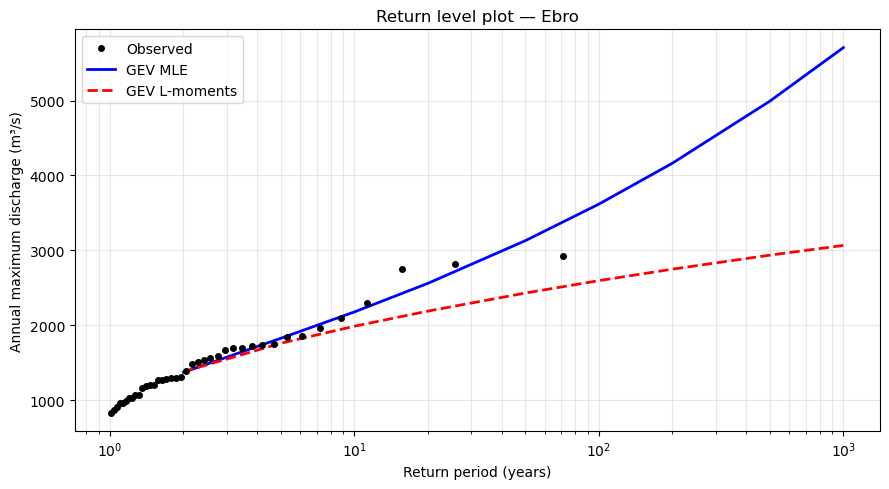

,MLE,L-mom
T,,
2,1374.0,1383.0
5,1828.0,1761.0
10,2180.0,1989.0
20,2562.0,2191.0
50,3130.0,2432.0
100,3618.0,2597.0
200,4165.0,2751.0
500,4991.0,2937.0
1000,5706.0,3067.0


In [8]:
T_values = [2, 5, 10, 20, 50, 100, 200, 500, 1000]

rl_mle  = [return_level(params_mle,  T) for T in T_values]
rl_lmom = [return_level(params_lmom, T) for T in T_values]

# Empirical plotting position (Gringorten)
data_sorted = np.sort(data)
n = len(data_sorted)
prob = (np.arange(1, n + 1) - 0.44) / (n + 0.12)
T_emp = 1.0 / (1.0 - prob)

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(T_emp, data_sorted, 'ko', ms=4, label="Observed", zorder=4)
ax.semilogx(T_values, rl_mle,  'b-',  lw=2, label="GEV MLE")
ax.semilogx(T_values, rl_lmom, 'r--', lw=2, label="GEV L-moments")
ax.set_xlabel("Return period (years)")
ax.set_ylabel("Annual maximum discharge (m³/s)")
ax.set_title(f"Return level plot — {station_name}", fontsize=12)
ax.legend()
ax.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Table
rl_df = pd.DataFrame({"T": T_values, "MLE": np.round(rl_mle, 0), "L-mom": np.round(rl_lmom, 0)})
rl_df.set_index("T", inplace=True)
rl_df

### Bayesian return levels with credible intervals

When `fit_gev_bayes` is available, `return_level_bayes` extracts posterior
quantiles to build a credible interval around the return level curve.

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


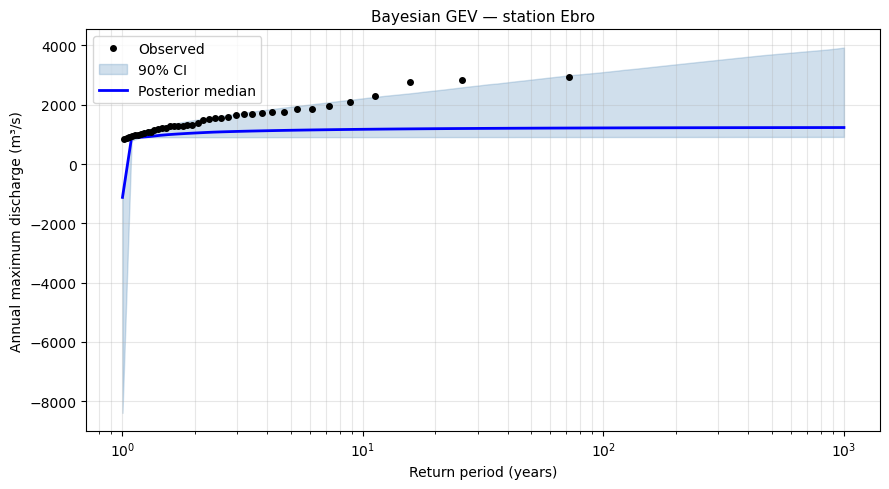

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(T_emp, data_sorted, "ko", ms=4, label="Observed", zorder=4)

# Build the posterior return level curve with a 90 % credible band.
# Samples with extreme xi (> 0.8) can produce very large / infinite return levels
# for long return periods — filter them before computing quantiles to avoid NaN.
T_fine   = np.logspace(0, 3, 80)
medians, lowers, uppers = [], [], []
for T in T_fine:
    levels = np.array([
        return_level_bayes(posterior.iloc[[i]], T, credible=0.90)["median"]
        for i in range(len(posterior))
    ])
    # Keep only finite, physically plausible samples
    levels = levels[np.isfinite(levels) & (levels < 1e7)]
    medians.append(float(np.median(levels)))
    lowers.append(float(np.quantile(levels, 0.05)))
    uppers.append(float(np.quantile(levels, 0.95)))

ax.fill_between(T_fine, lowers, uppers, alpha=0.25, color="steelblue", label="90% CI")
ax.semilogx(T_fine, medians, "b-", lw=2, label="Posterior median")
ax.set_xlabel("Return period (years)")
ax.set_ylabel("Annual maximum discharge (m³/s)")
ax.set_title(f"Bayesian GEV — station {station_name}", fontsize=11)
ax.legend()
ax.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.show()


---
## 2. Regional frequency analysis — Index Flood method

The **index flood** approach:
1. Normalise each station's series by its mean (index flood = mean).
2. Pool all normalised series into a single regional dataset.
3. Fit one GEV to the pooled data.
4. Rescale return levels back to each station by multiplying by its mean.

This borrows strength from the whole region — especially important for short
records.

In [10]:
_, index_floods = regional_index_flood(am_data)
print("Index floods (mean annual maximum, m³/s):")
for name, val in index_floods.items():
    print(f"  {name:<15}: {val:.0f}")

Index floods (mean annual maximum, m³/s):
  Ebro           : 1504
  Tajo           : 1003
  Duero          : 1280
  Guadalquivir   : 895
  Turia          : 482
  Segura         : 329
  Miño           : 844
  Jucar          : 436


In [11]:
# Fit regional GEV
regional_params, _ = fit_regional_gev(am_data, method="lmom")   # or 'mle'
print("\nRegional GEV parameters (L-moments):")
print(f"  mu = {regional_params['mu']:.3f}  sigma = {regional_params['sigma']:.3f}  xi = {regional_params['xi']:.3f}")
print("  (fitted to standardised series — all means ≈ 1.0)")


Regional GEV parameters (L-moments):
  mu = 0.843  sigma = 0.246  xi = -0.058
  (fitted to standardised series — all means ≈ 1.0)


In [12]:
# Regional return levels at all stations
T_values = [2, 5, 10, 25, 50, 100, 200, 500]
rl_regional = regional_return_levels(am_data, T_values=T_values, method="lmom")
print("Regional return levels (m³/s):")
rl_regional.round(0)

Regional return levels (m³/s):


,T2,T5,T10,T25,T50,T100,T200,T500
Ebro,1403.0,1799.0,2048.0,2348.0,2559.0,2761.0,2954.0,3198.0
Tajo,936.0,1200.0,1366.0,1566.0,1707.0,1842.0,1971.0,2133.0
Duero,1194.0,1531.0,1743.0,1998.0,2178.0,2350.0,2514.0,2721.0
Guadalquivir,834.0,1070.0,1218.0,1396.0,1522.0,1642.0,1757.0,1902.0
Turia,450.0,577.0,656.0,752.0,820.0,885.0,947.0,1025.0
Segura,306.0,393.0,447.0,513.0,559.0,603.0,645.0,698.0
Miño,787.0,1010.0,1149.0,1317.0,1436.0,1549.0,1658.0,1794.0
Jucar,406.0,521.0,593.0,680.0,741.0,800.0,856.0,926.0


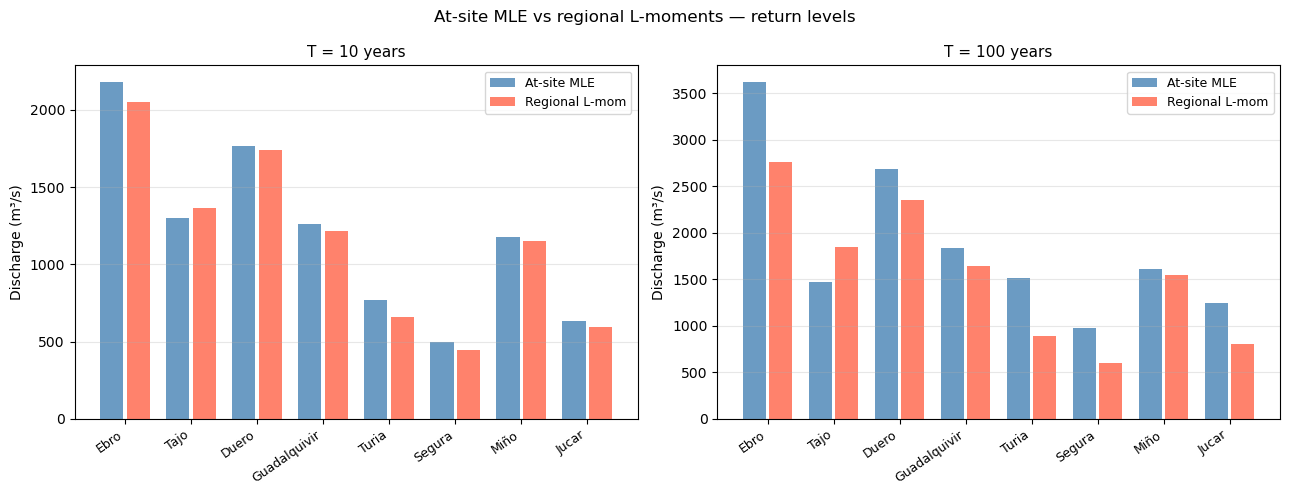

In [13]:
# Compare at-site MLE vs regional L-mom for each station
station_names = list(am_data.keys())
T_ref = [10, 100]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, T in zip(axes, T_ref):
    atsite = [
        return_level(fit_gev_mle(am_data[n]), T)
        for n in station_names
    ]
    regional = rl_regional[f"T{T}"].values

    x = np.arange(len(station_names))
    ax.bar(x - 0.2, atsite,   width=0.35, label="At-site MLE",    color="steelblue", alpha=0.8)
    ax.bar(x + 0.2, regional, width=0.35, label="Regional L-mom", color="tomato",    alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(station_names, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Discharge (m³/s)")
    ax.set_title(f"T = {T} years", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("At-site MLE vs regional L-moments — return levels", fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Hosking & Wallis heterogeneity check

Before applying a regional model it is good practice to test whether the sites
belong to a homogeneous region. A simple check is to compare the coefficient
of L-variation (L-CV) across stations — they should be similar.

Ebro            0.188
Tajo            0.140
Duero           0.162
Guadalquivir    0.172
Turia           0.249
Segura          0.218
Miño            0.171
Jucar           0.183
Name: L-CV, dtype: float64

L-CV range: 0.140 – 0.249
Coefficient of variation of L-CV: 0.184
(< 0.15 suggests acceptable homogeneity)


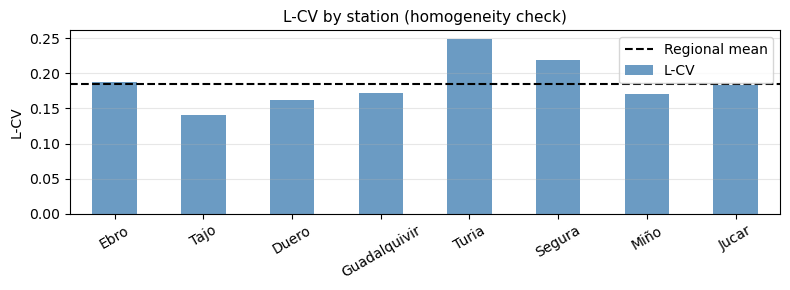

In [14]:
try:
    import lmoments3
    from lmoments3 import lmom_ratios

    lcv = {}
    for name, vals in am_data.items():
        lm = lmom_ratios(vals, nmom=4)
        lcv[name] = lm[1] / lm[0]  # L-CV = L2/L1

    lcv_series = pd.Series(lcv, name="L-CV")
    print(lcv_series.round(3))
    print(f"\nL-CV range: {lcv_series.min():.3f} – {lcv_series.max():.3f}")
    print(f"Coefficient of variation of L-CV: {lcv_series.std() / lcv_series.mean():.3f}")
    print("(< 0.15 suggests acceptable homogeneity)")

    fig, ax = plt.subplots(figsize=(8, 3))
    lcv_series.plot(kind="bar", ax=ax, color="steelblue", alpha=0.8)
    ax.axhline(lcv_series.mean(), color="k", lw=1.5, ls="--", label="Regional mean")
    ax.set_ylabel("L-CV")
    ax.set_title("L-CV by station (homogeneity check)", fontsize=11)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("(lmoments3 not installed — pip install lmoments3)")

---
## 4. Flood frequency map

Interpolate regional return levels onto a spatial grid using IDW to produce a
flood frequency map — combines `regional_return_levels` with
`IDWInterpolator`.

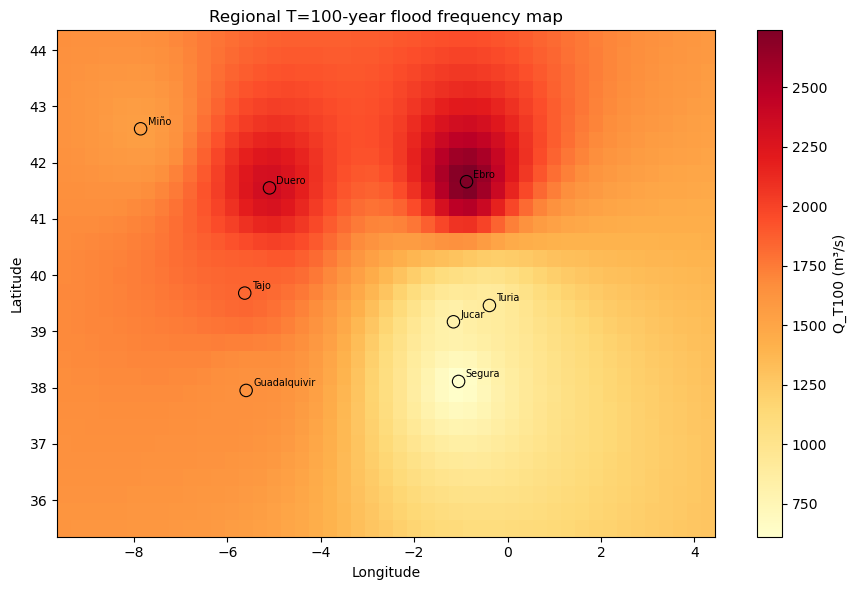

In [15]:
from pyhydra.climate.spatial_analysis import IDWInterpolator

# Approximate station coordinates (Iberian Peninsula)
station_coords = pd.DataFrame({
    "lon": [-0.88, -5.63, -5.10, -5.60, -0.39, -1.05, -7.86, -1.16],
    "lat": [41.66, 39.68, 41.55, 37.95, 39.46, 38.11, 42.60, 39.17],
}, index=station_names)

# Grid for Spain
glon2 = np.arange(-9.5, 4.5, 0.3)
glat2 = np.arange(35.5, 44.5, 0.3)
GLON2, GLAT2 = np.meshgrid(glon2, glat2)
grid2 = pd.DataFrame({"lon": GLON2.ravel(), "lat": GLAT2.ravel()})

T_map = 100
station_coords[f"T{T_map}"] = rl_regional[f"T{T_map}"].values

idw_rfa = IDWInterpolator(power=2)
idw_rfa.fit(station_coords, x_col="lon", y_col="lat", value_col=f"T{T_map}")
rl_map = idw_rfa.predict(grid2, x_col="lon", y_col="lat")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.pcolormesh(GLON2, GLAT2, rl_map.reshape(GLAT2.shape),
                   cmap="YlOrRd", shading="auto")
ax.scatter(station_coords.lon, station_coords.lat,
           c=station_coords[f"T{T_map}"], cmap="YlOrRd",
           edgecolors="k", s=80, zorder=3, linewidths=0.8)
for i, name in enumerate(station_names):
    ax.annotate(name, (station_coords.lon.iloc[i], station_coords.lat.iloc[i]),
                textcoords="offset points", xytext=(5, 3), fontsize=7)
plt.colorbar(im, ax=ax, label=f"Q_T{T_map} (m³/s)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Regional T={T_map}-year flood frequency map", fontsize=12)
plt.tight_layout()
plt.show()